## Exercise 1 Pearsons correlation

The pearsons correlation coefficient is a measure for linear similarity between to data sets $y_i$ $x_i$

There are several ways to look at the coefficient.

But first it is convenient to center the data around the averages $\bar{x}=\frac{1}{n}\sum_{i=1}^n$

So we have data
\begin{align*}
\tilde{x}_i= x_i-\bar{x}\\
\tilde{y}_i= y_i-\bar{y}\\
\end{align*}

One way to look at the problem of whether this two data sets are linear dependent is to ask? Are the vectors linear dependent.

But as we know this is the case if the angle between them is close to $0$ or $\pi$ put in another way $\cos(\theta)=1$ or $\cos(\theta)=-1$
So a measure of linear similarity is
$$
 \rho=\frac{\langle \tilde{x},\tilde{y}\rangle}{\lVert \tilde{x}\rVert \lVert \tilde{y}\rVert}=cos(\theta)
$$
 The similarity is high if this value approaches $1$ or $-1$, which is equivalent to $\theta=0$ or $\theta=\pi$. In which case the vectors ar parallel or antiparallel.

The coefficient $\rho$ can also be stated as
$$
 \rho=\frac{ \sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^n (x_i-\bar{x})^2\sum_{i=1}^n (y_i-\bar{y})^2} }
$$

This coefficient comes right out of least square method on the data $\tilde{y}_i$  linear modeled by $\tilde{x}_i$ and. The $R^2 =\rho$

Try to see if you can  derive this!!


Below are functions for generating data with noise


In [2]:
import numpy as np
def line_data(coefficient):
    np.random.seed(0)
    x_lin = np.random.uniform(0, 50, 100)
    y_lin = coefficient * x_lin + np.random.normal(0, 5, 100)
    return x_lin, y_lin


def random_data():
    x_rand = np.random.uniform(0, 50, 100)
    y_rand = np.random.uniform(0, 50, 100)
    return x_rand, y_rand


def circular_data():
    theta = np.linspace(0, 2 * np.pi, 100)
    r = 10
    x_circ = r * np.cos(theta) + np.random.normal(0, 0.5, 100)
    y_circ = r * np.sin(theta) + np.random.normal(0, 0.5, 100)
    return x_circ, y_circ

#### Task 1
Construct a function for calculating $\rho$


#### Task 2
Calculate and print the pearson coefficient for each data set. Make some conclusion

## Exercise 2 K-Means Clustering

The data obtained below is measurement of four traits of 150 flowers the idea is that there are **three** actual species
in the data so clustering by three points seem reasonable.

Try to implement k-Means clustering on the data `X`

```python
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
```



## Exercise 3
Linear maps

Consider the following basis map in $\mathbb{R}^2$
\begin{align*}
R_\theta(\mathbf{e}_1)&=\cos(\theta)\mathbf{e}_1+\sin(\theta)\mathbf{e}_2\\
R_\theta(\mathbf{e}_2)&=-\sin(\theta)\mathbf{e}_1+\cos(\theta)\mathbf{e}_2
\end{align*}

Assume that the basis $\mathbf{e}_i $ is the standard basis. So the map $R_\theta$ is from the standard basis

By linear continuation the map is fixed for all  $\mathbb{R}^2$

#### Task 1
Determine the coordinate representation for the map $R_\theta$.



#### Task 2
The basis change matrix is as you might remember the inverse of this matrix

The inverse of a two by two matrix
\begin{align*}
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}^{-1}
=
\frac{1}{ad-cb}
\begin{bmatrix}
d & -b \\
-c & a
\end{bmatrix}
\end{align*}

Determine the coordinate transformation map


#### Task 3
If you have coordinates say $(r\cos(\theta),r\sin(\theta))$ in the standard basis then the coordinates become?
Calculate the coordinates in the new basis


#### Task 4

If you have coordinates say $(r\cos(\theta+\frac{\pi}{2}),r\sin(\theta+\frac{\pi}{2})$ in the standard basis then the coordinates become?

Calculate the coordinates in the new basis


And what if we map the coordinates $(r\cos(\theta-\frac{\pi}{2}),r\sin(\theta-\frac{\pi}{2})$


#### Exercise 4
If you have two invertible matrices $A$ and $B$ and you want to calculate the inverse of the product $(AB)^{-1}$ can you prove that this can be calculated by

$$
(AB)^{-1}=B^{-1}A^{-1}
$$


#### Exercise 5

Composition of maps

Again consider our previous map

\begin{align*}
R_\theta(\mathbf{e}_1)&=\cos(\theta)\mathbf{e}_1+\sin(\theta)\mathbf{e}_2\\
R_\theta(\mathbf{e}_2)&=-\sin(\theta)\mathbf{e}_1+\cos(\theta)\mathbf{e}_2
\end{align*}
Where $\mathbf{e}_i$ is the standard basis

This map has been implemented in the code below to rotate an image

In the code you can compose several maps on an image by constructing more linear maps and combine them if you want

Try to experiment with some very basic maps and see what the limits of linear maps are as image altering maps.



3


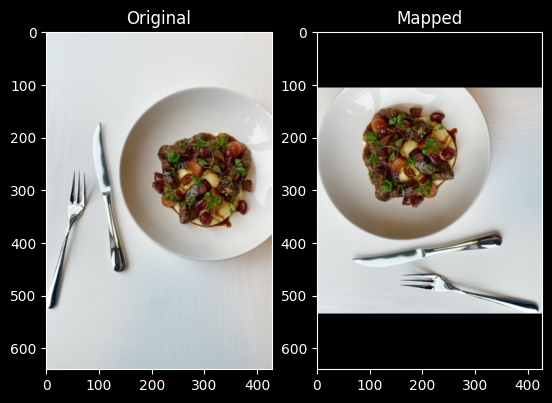

In [1]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from functools import partial



def rotation(vectors,angle):
    matrix = np.array([[np.cos(angle), -np.sin(angle)],
                       [np.sin(angle), np.cos(angle)]])
    return matrix @ vectors



def compose_linear_maps(maps,vectors):
    for i in range(len(maps)):
        vectors=maps[i](vectors)

    return vectors


# --- Load image and convert to grayscale ---
img = imageio.imread("data/food.jpg")
print(img.ndim)

H, W, C = img.shape

# --- Create coordinate grid ---
y, x = np.indices((H, W))
x0 = x - W / 2
y0 = y - H / 2



# --- Apply maps ---
coords = np.stack([x0, y0], axis=0).reshape(2, -1)


## Composition of linear maps

coords_rot = compose_linear_maps([partial(rotation,angle=np.pi/4),partial(rotation,angle=np.pi/4)], coords)


x_rot = coords_rot[0, :].reshape(H, W) + W / 2
y_rot = coords_rot[1, :].reshape(H, W) + H / 2

# --- Nearest-neighbor sampling ---
x_rot = np.round(x_rot).astype(int)
y_rot = np.round(y_rot).astype(int)

rotated = np.zeros_like(img)

valid = (x_rot >= 0) & (x_rot < W) & (y_rot >= 0) & (y_rot < H)
rotated[valid] = img[y_rot[valid], x_rot[valid]]

# --- Show original and rotated ---
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(rotated)
plt.title("Mapped")
plt.show()
